# Notebook 1 - DATABASE SELECTION AND SANITY CHECK FOR PYCALPHAD
 
**Reference:** Xu et al. 2025, *J. Mater. Res. Technol.* 35, 4779–4791  
**Databases evaluated:** `COST507-modified.tdb` `Fe-Ni-Ti_DeKeyzer2009.tdb` `mc_fecocrnbti.tdb` `mc_fe_v2062_clean.tdb`

## sanity check

In [ ]:
import pycalphad
print(dir(pycalphad))
print(pycalphad.__file__)


## database check 

In [2]:
from pycalphad import Database
from tinydb import where
from itertools import combinations

TARGET = {'FE', 'NI', 'CO', 'MO', 'TI', 'AL'}

def check_db(path, name):
    db = Database(path)
    db_elements = db.elements - {'VA', '/-'}

    print(f"\n{'='*55}")
    print(f"DATABASE: {name}")
    print(f"{'='*55}")
    print(f"All elements : {sorted(db_elements)}")
    print(f"Missing (ours): {sorted(TARGET - db_elements) or 'None'}")

    interactions = set()
    for phase_name in db.phases.keys():
        for param in db._parameters.search(where('phase_name') == phase_name):
            species = set()
            for subl in param['constituent_array']:
                for sp in subl:
                    el = str(sp).split(':')[0].upper()
                    if el != 'VA':
                        species.add(el)
            if len(species) >= 1:
                interactions.add(frozenset(species))

    for n, label in [(1,'UNARY'), (2,'BINARY'), (3,'TERNARY')]:
        hits = sorted([tuple(sorted(x)) for x in interactions
                       if len(x) == n])
        ours = [i for i in hits if set(i).issubset(TARGET)]
        print(f"\n--- {label} ({len(hits)} total, {len(ours)} relevant) ---")
        for i in hits:
            tag = " [OUR]" if set(i).issubset(TARGET) else ""
            print(f"  {i}{tag}")

    # coverage summary
    found = set(frozenset(x) for x in interactions)
    for n, label in [(2,'BINARY'), (3,'TERNARY')]:
        needed = [frozenset(p) for p in combinations(TARGET, n)]
        missing = sorted([tuple(sorted(x)) for x in needed if x not in found])
        print(f"\nMissing {label}: {missing or 'None'}")

    print(f"\nPhases: {sorted(db.phases.keys())}")

# run on all databases
# check_db("../databases/COST507-modified.tdb", "COST507")
# check_db("../databases/Fe-Ni-Ti_DeKeyzer2009.tdb", "Fe-Ni-Ti_DeKeyzer2009")
# check_db("../databases/mc_fecocrnbti.tdb", "mc_fecocrnbti")
# check_db("../databases/mc_fe_v2062_clean.tdb", "mc_fe_v2062_clean (MatCalc Steel Cleaned)")
check_db("../2databases/mc_fe_v2062_clean.tdb", "mc_fe_v2062_clean MANUALLY (MatCalc Steel Cleaned)")

/run/media/adi/New Volume/conda-envs/struct/lib/python3.11/site-packages/pycalphad/io/tdb.py:995: UserWarning: The type definition character `%` was defined in the following phases: ['LIQUID', 'FCC_A1', 'BCC_A2', 'H_BCC', 'HCP_A3', 'ALPHA_MN', 'BETA_MN', 'BETA_RHOMBO_B', 'DIAMOND_A4', 'GRAPHITE', 'BCC_B2', 'NISI', 'CHI_A12', 'CO3MO', 'CO3V', 'COV3', 'CR3MN5', 'G_PHASE', 'C15_LAVES', 'GAMMA_PRIME', 'LAVES_PHASE', 'MNNI', 'MNNI2', 'T2_MNNISI', 'T4', 'T7', 'MU_PHASE', 'MU_PHASE_I', 'NI2SIH', 'NI2SIL', 'NI3SI2', 'NI3SIH', 'NI3SIL', 'NI5SI2', 'ETA', 'NITI2', 'PI_PHASE', 'R_PHASE', 'SIGMA', 'FE17Y2', 'NI5Y', 'PDFE_L12', 'PDMN_AF', 'PDMN_P', 'PDMN_B2', 'PD2MN', 'PD3MN', 'PD5MN3', 'PD6FE5MN2', 'CEMENTITE', 'CR2VC2', 'K_CARB', 'KSI_CARBIDE', 'M3C2', 'M6C', 'M7C3', 'M12C', 'M23C6', 'MOC_ETA', 'V3C2', 'WC', 'EPS_CARB', 'ETA_CARB', 'FE24C10', 'KSI_FE5C2', 'ALN', 'ALN_EQU', 'BN_HP4', 'FE4N', 'MN6N4', 'MN6N5', 'MNSIN2', 'SI3N4', 'TAN_EPS', 'ZET', 'CRB', 'CR2B', 'CR5B3', 'FEB', 'FENBB', 'FE3NB3B4', '


DATABASE: mc_fe_v2062_clean MANUALLY (MatCalc Steel Cleaned)
All elements : ['AL', 'B', 'C', 'CO', 'CR', 'CU', 'FE', 'H', 'HF', 'LA', 'MN', 'MO', 'N', 'NB', 'NI', 'O', 'P', 'PD', 'S', 'SI', 'TA', 'TI', 'V', 'W', 'Y']
Missing (ours): None

--- UNARY (24 total, 6 relevant) ---
  ('AL',) [OUR]
  ('B',)
  ('C',)
  ('CO',) [OUR]
  ('CR',)
  ('CU',)
  ('FE',) [OUR]
  ('HF',)
  ('LA',)
  ('MN',)
  ('MO',) [OUR]
  ('N',)
  ('NB',)
  ('NI',) [OUR]
  ('O',)
  ('P',)
  ('PD',)
  ('S',)
  ('SI',)
  ('TA',)
  ('TI',) [OUR]
  ('V',)
  ('W',)
  ('Y',)

--- BINARY (176 total, 14 relevant) ---
  ('*', 'C')
  ('*', 'N')
  ('AL', 'B')
  ('AL', 'C')
  ('AL', 'CR')
  ('AL', 'CU')
  ('AL', 'FE') [OUR]
  ('AL', 'HF')
  ('AL', 'MN')
  ('AL', 'MO') [OUR]
  ('AL', 'N')
  ('AL', 'NB')
  ('AL', 'NI') [OUR]
  ('AL', 'O')
  ('AL', 'P')
  ('AL', 'SI')
  ('AL', 'TI') [OUR]
  ('AL', 'V')
  ('AL', 'W')
  ('B', 'C')
  ('B', 'CO')
  ('B', 'CR')
  ('B', 'CU')
  ('B', 'FE')
  ('B', 'HF')
  ('B', 'MN')
  ('B', 'MO')
  ('B'

# Database Selection Verdict

## Selected: `mc_fe_v2062_clean.tdb` (MatCalc Open Steel Database v2.062 - Cleaned for pycalphad)

### Why this database

- **Contains ALL SIX required elements**: Fe, Ni, Co, Mo, Ti, Al — no composition renormalization needed
- Defines the **ETA phase** (= Ni₃Ti, D024 hexagonal) — the central precipitate of this study
- Defines **LAVES_PHASE** (Fe₂Ti-type), **BCC_A2** (martensite), **FCC_A1** (austenite), **BCC_B2** (ordered BCC), **LIQUID**, and many more
- **Peer-reviewed and maintained** by TU Wien (Povoden-Karadeniz & Jacob) — not AI-generated
- **Explicitly designed for steel applications**, including "PH maraging steels"
- Cleaned of MatCalc-specific extensions and syntactic typos, making it fully compatible with pycalphad

### Why the others were rejected

| Database | Fatal flaw |
|---|---|
| `COST507` | Designed for aluminium alloys. **No NI3TI phase**, no FE-NI binary, no NI-TI binary. |
| `Fe-Ni-Ti_DeKeyzer2009` | AI-generated from paper — **unverified parameters**, at least one clear transcription error found (NITI2 Fe:Ni end-member). Only covers 3 elements (Fe,Ni,Ti), missing Co, Mo, Al. |
| `mc_fecocrnbti` | Has CO and FE-TI but **no NI element**, cannot model Ni₃Ti. |

---

## Known Limitations

### 1. Co slightly exceeds optimized range
The database is optimized for Co < 3 wt%, but our alloy has 8.5 wt% Co. Phase boundaries involving Co may be less accurate.

### 2. Mo at the optimization limit
The database is optimized for Mo < 5 wt%, matching our alloy exactly at 5 wt%.

### 3. Equilibrium ≠ Kinetics
pycalphad computes thermodynamic equilibrium. It cannot capture kinetic effects like:
- Mo-enriched particle nucleation during DAT-1 (370°C)
- Sluggish diffusion at low aging temperatures
- Time-dependent precipitation sequences

### 4. Phase name mapping

| Old TDB name | mc_fe_v2062_clean name | Description |
|---|---|---|
| `NI3TI` | `ETA` | Ni₃Ti, D024 hexagonal |
| `C14` | `LAVES_PHASE` | Unified C14/C15/C36 Laves |
| `A2` | `BCC_A2` | Disordered BCC |
| `A1` | `FCC_A1` | Disordered FCC |
| `A3` | `HCP_A3` | HCP |
| `BCC2` | `BCC_B2` | Ordered BCC (B2) |

## Database Sanity Check (Binary Phase Diagrams)

To validate the `mc_fe_v2062_clean.tdb` database parameters, we can plot the binary phase diagrams of Fe-Ni and Fe-Ti. These should match standard literature phase diagrams.
- **Fe-Ni** should show the classic $\gamma$-austenite (FCC) field and $\alpha$-ferrite (BCC) field.
- **Fe-Ti** should clearly show the Laves phase ($Fe_2Ti$) intermediate compound.


In [13]:
from pycalphad import Database, binplot
import pycalphad.variables as v
import matplotlib.pyplot as plt

# Suppress pycalphad warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# db = Database('../databases/mc_fe_v2062_clean.tdb')
db = Database('../databases/steel_database_fix.tdb')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Fe-Ni Binary ---
comps_feni = ['FE', 'NI', 'VA']
# Limit phases to main ones for speed and clarity
phases_feni = ['LIQUID', 'FCC_A1', 'BCC_A2', 'BCC_B2']
print("Calculating Fe-Ni binary phase diagram...")
binplot(db, comps_feni, phases_feni, {v.X('NI'): (0, 1, 0.02), v.T: (500, 2000, 20), v.P: 101325}, ax=axes[0])
axes[0].set_title("Fe-Ni Binary Phase Diagram")

# --- Fe-Ti Binary ---
comps_feti = ['FE', 'TI', 'VA']
phases_feti = ['LIQUID', 'FCC_A1', 'BCC_A2', 'HCP_A3', 'LAVES_PHASE']
print("Calculating Fe-Ti binary phase diagram...")
binplot(db, comps_feti, phases_feti, {v.X('TI'): (0, 1, 0.02), v.T: (500, 2000, 20), v.P: 101325}, ax=axes[1])
axes[1].set_title("Fe-Ti Binary Phase Diagram")

plt.tight_layout()
plt.show()
print("Plots generated.")


ParseException: Invalid TDB syntax.
   PARAMETER G(BCC_DISL,*:C,VA;1) 273.00 +500000-450*T; 1273.16  N   REF:TEST KOZE10 
                                                                              ^, found 'KOZE10'  (at char 129999), (line:4108, col:10)

In [3]:
print(f"Number of phases in database: {len(db.phases)}")

print("\nAll phases:")
for phase in sorted(db.phases.keys()):
    print(phase)

Number of phases in database: 132

All phases:
ALN
ALN_EQU
ALPHA_MN
ANILITE
A_CHALC
BCC_A2
BCC_B2
BCC_DISL
BETA_MN
BETA_RHOMBO_B
BN_HP4
B_CHALC
C15_LAVES
CEMENTITE
CHI_A12
CO3MO
CO3V
CORUND
COV3
COVELLITE
CR2B
CR2VC2
CR3MN5
CR5B3
CRB
CU2S
DIAMOND_A4
DIGENITE
DISULF
DJURLEITE
EPS_CARB
ETA
ETA_CARB
FCC_A1
FC_MONO
FE17Y2
FE24C10
FE3NB3B4
FE4N
FEB
FENBB
FES_P
GAMMA_PRIME
GRAPHITE
G_PHASE
HALITE
HCP_A3
HF1O2_C
HF1O2_M
HF1O2_T
H_BCC
KSI_CARBIDE
KSI_FE5C2
K_CARB
LA2O3_A
LA2O3_C
LA2O3_H
LAVES_PHASE
LIQUID
M12C
M23C6
M2B
M2P
M3C2
M3P
M5B6
M6C
M7C3
MN3B4
MN6N4
MN6N5
MNB2
MNB4
MNNI
MNNI2
MNSIN2
MNS_Q
MO2M1B2
MOB
MOB2
MOC_ETA
MU_PHASE
MU_PHASE_I
NB3B2
NBB
NI2SIH
NI2SIL
NI3SI2
NI3SIH
NI3SIL
NI5SI2
NI5Y
NISI
NITI2
O1_GAS
O_MN2B
PD2MN
PD3MN
PD5MN3
PD6FE5MN2
PDFE_L12
PDMN_AF
PDMN_B2
PDMN_P
PI_PHASE
PYRR
R_PHASE
SI3N4
SIGMA
SIO2
SPINEL
T2_MNNISI
T4
T7
TAN_EPS
TI2O3
TI3B4
TI4C2S2
TIB
TIB2
TIO2
TIS
TRID
V3C2
WC
Y2O3_C
Y2O3_H
Y2TI2O7
Y2TIO5
Y4AL2O9
YALO3
ZET


In [4]:
print("\nTi-related phases:")
for phase in sorted(db.phases.keys()):
    if 'TI' in phase.upper():
        print(phase)


Ti-related phases:
CEMENTITE
NITI2
TI2O3
TI3B4
TI4C2S2
TIB
TIB2
TIO2
TIS
Y2TI2O7
Y2TIO5


In [6]:
from pycalphad import equilibrium
import pycalphad.variables as v
import numpy as np

eq_fe = equilibrium(
    db,
    ['FE', 'VA'],
    ['BCC_A2', 'FCC_A1', 'LIQUID'],
    {
        v.T: np.arange(300, 2200, 10),
        v.P: 101325
    }
)

print(eq_fe.Phase.squeeze().values)

[['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2' '']
 ['BCC_A2'

<Figure size 1200x800 with 0 Axes>

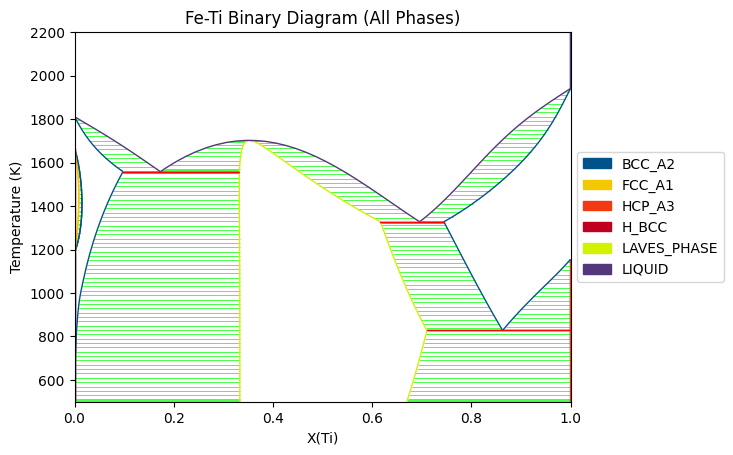

In [7]:
from pycalphad import binplot
import pycalphad.variables as v
import matplotlib.pyplot as plt

phases_feti = sorted(db.phases.keys())

plt.figure(figsize=(12,8))

binplot(
    db,
    ['FE', 'TI', 'VA'],
    phases_feti,
    {
        v.X('TI'): (0, 1, 0.02),
        v.T: (500, 2200, 20),
        v.P: 101325
    }
)

plt.title('Fe-Ti Binary Diagram (All Phases)')
plt.show()

<Figure size 1200x800 with 0 Axes>

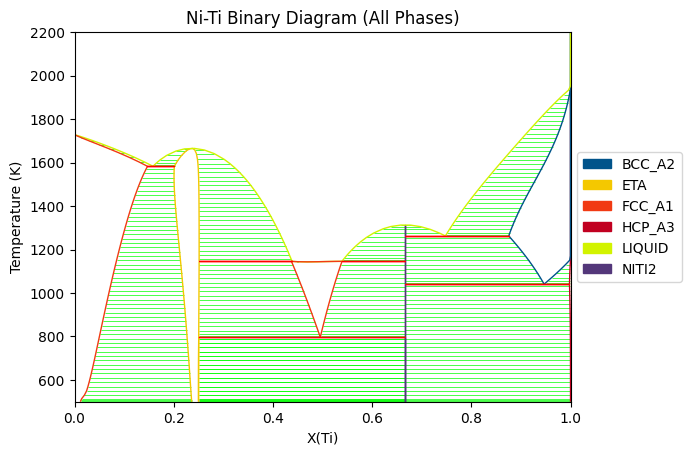

In [8]:
phases_niti = sorted(db.phases.keys())

plt.figure(figsize=(12,8))

binplot(
    db,
    ['NI', 'TI', 'VA'],
    phases_niti,
    {
        v.X('TI'): (0, 1, 0.02),
        v.T: (500, 2200, 20),
        v.P: 101325
    }
)

plt.title('Ni-Ti Binary Diagram (All Phases)')
plt.show()

<Figure size 1200x800 with 0 Axes>

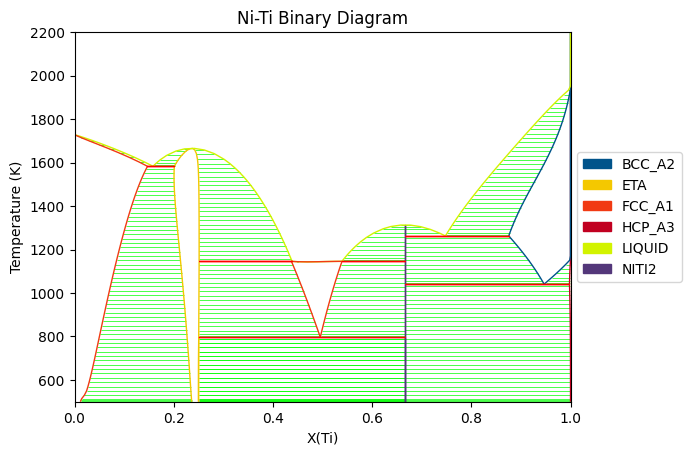

In [10]:
plt.figure(figsize=(12,8))

binplot(
    db,
    ['NI', 'TI', 'VA'],
    list(db.phases.keys()),
    {
        v.X('TI'): (0, 1, 0.02),
        v.T: (500, 2200, 20),
        v.P: 101325
    }
)

plt.title('Ni-Ti Binary Diagram')
plt.show()

In [9]:
print(sorted(db.phases.keys()))

['ALN', 'ALN_EQU', 'ALPHA_MN', 'ANILITE', 'A_CHALC', 'BCC_A2', 'BCC_B2', 'BCC_DISL', 'BETA_MN', 'BETA_RHOMBO_B', 'BN_HP4', 'B_CHALC', 'C15_LAVES', 'CEMENTITE', 'CHI_A12', 'CO3MO', 'CO3V', 'CORUND', 'COV3', 'COVELLITE', 'CR2B', 'CR2VC2', 'CR3MN5', 'CR5B3', 'CRB', 'CU2S', 'DIAMOND_A4', 'DIGENITE', 'DISULF', 'DJURLEITE', 'EPS_CARB', 'ETA', 'ETA_CARB', 'FCC_A1', 'FC_MONO', 'FE17Y2', 'FE24C10', 'FE3NB3B4', 'FE4N', 'FEB', 'FENBB', 'FES_P', 'GAMMA_PRIME', 'GRAPHITE', 'G_PHASE', 'HALITE', 'HCP_A3', 'HF1O2_C', 'HF1O2_M', 'HF1O2_T', 'H_BCC', 'KSI_CARBIDE', 'KSI_FE5C2', 'K_CARB', 'LA2O3_A', 'LA2O3_C', 'LA2O3_H', 'LAVES_PHASE', 'LIQUID', 'M12C', 'M23C6', 'M2B', 'M2P', 'M3C2', 'M3P', 'M5B6', 'M6C', 'M7C3', 'MN3B4', 'MN6N4', 'MN6N5', 'MNB2', 'MNB4', 'MNNI', 'MNNI2', 'MNSIN2', 'MNS_Q', 'MO2M1B2', 'MOB', 'MOB2', 'MOC_ETA', 'MU_PHASE', 'MU_PHASE_I', 'NB3B2', 'NBB', 'NI2SIH', 'NI2SIL', 'NI3SI2', 'NI3SIH', 'NI3SIL', 'NI5SI2', 'NI5Y', 'NISI', 'NITI2', 'O1_GAS', 'O_MN2B', 'PD2MN', 'PD3MN', 'PD5MN3', 'PD6FE

In [11]:
for phase in db.phases.keys():
    if phase in ['ETA', 'GAMMA_PRIME', 'NITI2', 'LAVES_PHASE']:
        print(phase)
        print(db.phases[phase])
        print("\n")

GAMMA_PRIME
Phase({'name': 'GAMMA_PRIME', 'constituents': (frozenset({Species('SI', 'SI1'), Species('FE', 'FE1'), Species('CR', 'CR1'), Species('TI', 'TI1'), Species('NI', 'NI1')}), frozenset({Species('SI', 'SI1'), Species('FE', 'FE1'), Species('CR', 'CR1'), Species('AL', 'AL1'), Species('TI', 'TI1'), Species('NI', 'NI1')})), 'sublattices': (0.25, 0.75), 'model_hints': {}})


LAVES_PHASE
Phase({'name': 'LAVES_PHASE', 'constituents': (frozenset({Species('V', 'V1'), Species('SI', 'SI1'), Species('FE', 'FE1'), Species('CR', 'CR1'), Species('MO', 'MO1'), Species('CO', 'CO1'), Species('TI', 'TI1'), Species('NB', 'NB1'), Species('W', 'W1'), Species('MN', 'MN1'), Species('NI', 'NI1')}), frozenset({Species('V', 'V1'), Species('SI', 'SI1'), Species('FE', 'FE1'), Species('CR', 'CR1'), Species('MO', 'MO1'), Species('CO', 'CO1'), Species('TI', 'TI1'), Species('NB', 'NB1'), Species('W', 'W1'), Species('MN', 'MN1'), Species('NI', 'NI1')})), 'sublattices': (2.0, 1.0), 'model_hints': {}})


ETA
Phase(